# MTH739 – Topics in Scientific Computing – Semester A 2024/25

## Coursework 1 : Trisolaris: the three body problem

## Section 1 : Instructions and important information

### 1.1 Important information about this project assignment

This is the assignment for the first coursework of MTH739 – Topics in Scientific Computing. This assignment is scored on a scale of 100, and will contribute 20% of your final mark.

Please read carefully through the paragraphs below, since they contain very important information about the submission deadline, procedures, expectations, etc.

### 1.2 Expectations

The project consists of 3 problems, each containing a single goal with multiple component parts. You are expected and encouraged to attempt every problem in this assignment. Fractional marks may be awarded for meaningful partial solutions, for example, a description in words/pseudocode of what you would do in principle to solve the problem, or implement a test. It will always be better to write something rather than nothing, since you can only gain (you won't lose marks for wrong answers).

You are expected to provide working Python code that answers each question, and to **accompany your code with appropriate documentation of the code appropriate for new users who have a basic familiarity with python and ODEs (your colleagues on this course, for example!)**. In particular, you should provide at least a brief text paragraph (using the markdown cells) that explains what you did, and you should use appropriate naming and include meaningful comments inside your code where necessary, to make it clear what the code does. Failing to provide comments and/or documentation will mean you cannot access the maximum mark. Marks will also be available for defensive programming techniques including asserts and tests of key functionality, where appropriate. You need to use your judgement for this - the code should prevent a slightly confused user from doing incorrect things or breaking code, and check that you implemented things correctly. 

The marks available for each section are indicated below. Broadly speaking, for each section, the marks available will be split as follows:

   - 60% for working code that correctly implements all of the requested components
   - 20% for use of defensive programming techniques - asserts and tests implemented to prevent user error and check the code is functioning correctly, including convergence testing.
   - 10% for readability of code, following the agreed naming conventions of the course, appropriate commenting
   - 10% for appropriate documentation of the code implemented in markdown format around the code.

Please read all sections and each question carefully before attempting an answer. This will help you to avoid misinterpreting the questions and you may be able to make your code more flexible at an earlier stage in order to be able to use it more efficiently later on.

You are mainly expected to develop your own code to solve the problems, even though python may already have a library function that performs the same task. Since the goal is to show that you understand the methods and how they are implemented, you should in general write your own code for an algorithm from scratch unless use of a specific function is indicated (obviously still using basic numpy, scipy and sympy functions like `np.sin()`, `np.array()`, `sp.symbol()` etc is fine!). As a general rule, I would recommend that you **do not use any functions outside of the sympy, numpy, matplotlib and scipy libraries**, as if you do you will very probably miss marks for showing how you implement the solution. This should be clear from the context but if you are in any doubt, **just ask**.

### 1.3 Submission procedure

You must use **this Jupyter Notebook** to develop your project, answer the questions, write the corresponding code, present the result in accordance to the requirements of each question, and include your comments and explanations.

You are not allowed to remove any cell from the present notebook. However, you can add as many text or code cells as needed.
You are expected to submit this Jupyter Notebook filled in with all your code, answers, comments, and nothing else. Please **do not rename this file** - all the submissions are automatically associated to your QMPlus Student ID and so you do not need to add any identifier. Note that you cannot submit any additional file.

All the submissions must be performed through QMPlus, using the appropriate submission system for this assignment -
you cannot submit your attempt in any other way! Submissions received through other means, including emails **will not be considered and will score a zero**.
Please read through the paragraph below about the submission deadline and the late submission policy.

### 1.4 Submission deadline

The submission deadline for this coursework is **17:00 UTC on Friday 22 November**.

Submissions received after that deadline will be treated in accordance with the College Regulations concerning late submissions. This means that late submissions will incur a penalty of 5% of the total marks for every day of delay (or fraction thereof), up to seven days after the submission deadline. For instance, a submission received with 24 hours of delay will incur a penalty of 10 marks of the 100 available. Any submission received more than 168 hours after the deadline stated above will score a zero.

The lecturer will be available to answer reasonable questions about this assignment up until Thursday 21st November 2024. You can contact the lecturer via email at _k.clough@qmul.ac.uk_. If information or tips are given to a student individually, this will then be communicated to the whole cohort via the course announcements, so everyone has the same guidance.

### 1.5 Third-party material and plagiarism policy

You must work independently on your project, and your submission should include only original material, code and comments, that you have produced by yourself. You are allowed to use any sources (books, internet, Google, etc.) to help you in completing this project, but you must cite them appropriately. The same applies to published code: if you use any publicly available code from a third party, you must cite the source appropriately, and specify what is your original contribution. 

You can use ChatGPT but I would advise you that those who did in prior years generally got poorer marks, because this course is quite specialised. In particular, ChatGPT does not follow the course coding conventions, and its text answers sounded clever but made no actual physical sense. Use it as an aid, not as a replacement for your own knowledge and judgement.

You are allowed to discuss the general approach to a question with your colleagues, but you cannot share your own code with colleagues or reuse code produced by your colleagues for this assignment.

Queen Mary University of London has in place a very efficient system for automatic plagiarism detection, which draws on a database of several million books, webpages, research articles, dissertations, and submissions to university-level modules from all over the world. All the material submitted for assessment is automatically processed by this system, which produces a detailed plagiarism report. If I suspect that any of the submitted material is plagiarised, the marks of the corresponding piece of assessment will be withheld until you can demonstrate that the code or material is genuinely your own. Any suspect case of copying or plagiarism will be referred to the School and the College for investigation. The typical outcome of a plagiarism investigation might be the failure of the corresponding piece of assessment, the failure of the module, or even the withdrawal of an awarded title and the expulsion from the College in more serious cases. Please refer to the QMUL Academic Regulations for more information about the definition of plagiarism and the relative penalties: https://arcs.qmul.ac.uk/students/student-appeals/assessment-offences/index.html

## Section 2 : Coursework background

This background will also be discussed in the Week 4 lecture, which will be recorded, so you should watch that if you did not attend.

### 2.1 Background

The broad goal of the project is to write code to model coplanar stellar systems (i.e., all the motion is in the x and y directions) with up to three stars.

In our solar system, we have only one star (the Sun!), and this dominates the motion of the other objects (like planets) that exist nearby. However, it is quite common to have two stars in a system, a so called "binary" star system, with the stars having a similar size and mass.

However, it is very uncommon to have three similar sized stars in a close orbit (although a third can orbit much further out around the first two). Why? As we will see in this coursework, triple systems are subject to chaotic behaviour and will generally not be stable over long periods of time.

*You don't really need to know anything about stars to do this coursework, you just need to solve the equations, but it can help to think about the physical system when you do this.*

### 2.2 The equations to solve

The equations you need to solve are as follows:

There are $N$ stars, labelled by an index $i=1,2...N$.

The position of star $i$ is $(x_i, y_i)$, its mass is $M_i$. The goal is to solve for the positions of all the $N$ stars as functions of time, given the initial values of each star's position $[x_i,y_i]$ and velocity $\left[\frac{dx_i}{dt},\frac{dy_i}{dt}\right]$ at $t=0$. However, to solve for any one we will need to know the position of all the other stars - the systems are *coupled*.

_(HINT Notice that this is a set of coupled 2nd order ODEs, so we need to apply what we learned in the course about dealing with higher order ODEs. How many dependent variables will we have in the state vector if we have N stars?)_

The ODE for the x position of each star is:

\begin{equation}
\frac{d^2 x_i }{ dt^2 } = \sum^{j=N}_{j=1, j\neq i} \frac{G M_j}{r^2_{ij}} \cos(\theta)
\end{equation}

and for the y position:

\begin{equation}
\frac{d^2 y_i }{ dt^2 } = \sum^{j=N}_{j=1, j\neq i} \frac{G M_j}{r^2_{ij}} \sin(\theta)
\end{equation}

where 

$r_{ij} = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$

$\cos{\theta} = (x_j - x_i) / r_{ij}$

$\sin{\theta} = (y_j - y_i) / r_{ij}$


### 2.3 Note on units and initial conditions

You should set $G=1$, so that you work in units in which the masses of the stars are order 1 numbers, as are the values of $r_{ij}$ (roughly speaking you are choosing the length units to be equal to the mass units). Note that what I call an order 1 number here is anything in the range from 0.1-10!

We want our coordinate reference frame to be fixed to the stars' centre of mass, which means that we need to have zero initial net momentum in the system. Taking the binary system for example, initially we should have:

$M_1 \frac{dx_1}{dt} + M_2 \frac{dx_2}{dt} = 0$

$M_1 \frac{dy_1}{dt} + M_2 \frac{dy_2}{dt} = 0$

This allows us to find the initial velocity of the second star if the first is given.

### 2.4 Where do the above equations come from?

Let's consider a two body system for simplicity. This is made up of two stars that obey Newton's law of gravitation:

$\vec{F}_{12} = - \frac{G M_1 ~ M_2 }{r_{12}^2} \frac{\vec{r}_{12}}{|\vec{r}_{12}|}$

We also know that Newton's second law is:

$\vec{F} = M \frac{d^2 \vec{x}}{dt^2}$
    
We can treat the $x$ and $y$ components separately so that for the first star, its $x$ position obeys:

$ M_1 \frac{d^2 x_1}{dt^2} = \frac{G M_1 ~ M_2 }{r_{12}^2} \cos(\theta)$

Where we have projected the component of the force into the x axis, with $r_{12} = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$ and $\cos{\theta} = (x_2 - x_1) / r_{12}$.

Note that the mass of the star $M_1$ cancels on both sides (not a conincidence, but a fundamental property of gravity), so we recover the expressions above where the mass of the star itself does not appear in its acceleration (only the masses of the other stars). We can do the same for the other components and the other stars.

## Section 3 : Coursework problems

### 3.1 Problem 1: Binary system (45% of marks)

Model a two body system made up of two stars undergoing multiple stable orbits. 

**Required Components**

1. The first star should start at position $[x_1,y_1] = [2.0,0.0]$ with velocity $\left[\frac{dx_1}{dt},\frac{dy_1}{dt}\right] = [0.0,-0.1]$. Put the second star at $[x_1,y_1] = [-2.0,0.0]$ and use the expression above to find its initial velocity so that the stars orbits are fixed with respect to the coordinate axes.

2. The mass ratio of the stars should be $M_1/M_2 = 2$ 

3. You should write one class to represent stars, and another for star systems (don't forget the naming conventions of the course!)

4. Provide plots of the trajectories for all the stars, and a phase diagram for the position and velocity of one of the component stars

_NB I prefer that you do not provide animations, as these sometimes don't work on different systems and require additional python packages, but if you do you must also provide static plots that illustrate the results. It is an important and useful skill to be able to represent time varying data using static plots._

5. Compare two explicit integration techniques - the first should be scipy's solve_ivp() and the second should be the midpoint method (or another Runge Kutta method of specified order)

6. For the midpoint/Runge Kutta method, provide a convergence test confirming that the solution converges at the required order

7. Give two reasons why it is better to use the midpoint method than Euler's method

8. Include defensive programming techniques such as asserts and tests of key functionality

9. Provide some documentation of the code implemented in markdown

_(HINT 1: you may want to investigate the rtol parameter for solve_ivp() when you show multiple orbits)_

_(HINT 2: try to think ahead - what features of problem 1 might you want to reuse in problems 2 and 3? You can save time coding by making it sufficiently general from the start)_

# Coursework answers : #
## Section 3 : ##
### 3.1 Problem 1: Binary system ###

Before we start solving the coursework we need to define some libraries:

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

The aim of this coursework is to solve these 2 ODEs for the x position for the stars:

\begin{equation}
\frac{d^2 x_i }{ dt^2 } = \sum^{j=N}_{j=1, j\neq i} \frac{G M_j}{r^2_{ij}} \cos(\theta)
\end{equation}

and for the y position for the stars:

\begin{equation}
\frac{d^2 y_i }{ dt^2 } = \sum^{j=N}_{j=1, j\neq i} \frac{G M_j}{r^2_{ij}} \sin(\theta)
\end{equation}

We identify the variables:
     
     - Two dependent variables : x position and y position for each star.
     - and Two more : velocity in the x and y direction.
     
     So we have 4 dependent variables in total.
     
Because this is a second order ODE,  when we change it to first oder ODE we end up with the velocity in the x and the y direction as additional variables.

### Defining Classes : ###


To model a two body system made up of two stars undergoing multiple stable orbits we need to define two classes:

    1- Stars : this class will represent individual stars, storing their 
    mass, position, and velocity.

    2- StarSystem : This class will represent the system of stars and will handle the numerical integration of their motion.

In [2]:
#Star Class

class Stars :
    """ 
    Class to represent a star in a binary star system.
    
    Attributes: 
    
    - mass (float): Mass of the star (must be positive).
    - position (numpy array): Initial position of the star as a numpy array of shape (2,) representing [x, y] coordinates.
    - velocity (numpy array): Initial velocity of the star as a numpy array of shape (2,) representing [vx, vy].
    
    Methods: 
    - __repr__: Provides a readable string representation of the star's attributes.
    
    
    """
    
    
    # Constructor Function
    def __init__(self, mass, position, velocity):
        
        # Initialise a star object with mass, position, and velocity.
        
        if mass <= 0:
            raise ValueError("Mass must be a positive value.")

        
        # we could have another assert here to check that the position and the velocity of the stars are 
        # given in a numpy array of length 2 
        
        if isinstance(position, (list, np.ndarray)) and len(position) == 2:
            self.position = np.array(position, dtype=float)
        else:
            raise ValueError("Position must be a list or numpy array of length 2.")

        if isinstance(velocity, (list, np.ndarray)) and len(velocity) == 2:
            self.velocity = np.array(velocity, dtype=float)
        else:
            raise ValueError("Velocity must be a list or numpy array of length 2.")

       
        self.mass = mass
        self.position = np.array(position, dtype=float)
        self.velocity = np.array(velocity, dtype=float)

        
    def __repr__(self):
        """
        String representation of the Star object.
        """
        return f"Star(mass={self.mass}, position={self.position}, velocity={self.velocity})"


After defining the **Star** class, I considered potential issues that might arise during instantiation. One possible problem is mistakenly inputting a negative or zero value for mass, which is physically unrealistic. To address this, I added an assertion in the constructor function to ensure that the mass is strictly greater than zero.

While implementing this check, I realised that the position and velocity attributes also required validation. These attributes must be either lists or NumPy arrays, each containing exactly two elements to represent the x and y coordinates (for position) and the velocity components (for velocity). To enforce this, I added assertions to verify that both position and velocity adhere to the required format.

However, I was unsure if my assertions were functioning as intended, since I never used isinstance() before. To resolve this uncertainty, I decided to test the class with an example to ensure the validation logic behaves as expected. This process of testing is demonstrated in the code provided below.

In [3]:
#star1 = Stars(2.0, [1.0], [0.0, 1.0])
#star1.mass

For instance when I run the code above, it throws an error:

    ValueError: Position must be a list or numpy array of length 2.


The assert below was my alternative in case the previous one did not work.
    
    assert len(position) == 2 and len(velocity) == 2, "Position and velocity must be 2D vectors"

Now that the **Stars** class is defined, I move onto using it to find the velocity of the second star.

To do this, we use the condition of zero net momentum for the system:

$M_1 \frac{dx_1}{dt} + M_2 \frac{dx_2}{dt} = 0$

$M_1 \frac{dy_1}{dt} + M_2 \frac{dy_2}{dt} = 0$

Given M1= 2*M2, and substituting the velocity of Star1, we can solve for Star2's initial velocity to ensure momentum conservation.

For simplicity I use mass1 = 2.0 for star 1.

In [3]:
# Define the masses while ensuring the mass ratio M1/M2 = 2

mass1 = 2.0  # Mass of the first star
mass2 = mass1 / 2.0  # Mass of the second star to maintain the ratio


# Create the first star at position [2.0, 0.0] with velocity [0.0, -0.1]
star1_position = np.array([2.0, 0.0])
star1_velocity = np.array([0.0, -0.1])

# Create the second star at position [-2.0, 0.0]
star2_position = np.array([-2.0, 0.0])

vx1, vy1 = star1_velocity  # Unpack velocity of star1 --> in vector form

# Solve for initial velocity of the second star
vx2 = -(mass1 * vx1) / mass2
vy2 = -(mass1 * vy1) / mass2

star1 = Stars(mass1, star1_position, star1_velocity)
star2 = Stars(mass2, star2_position, np.array([vx2, vy2]))

print(f"Star 1: Position = {star1.position}, Velocity = {star1.velocity}, Mass = {star1.mass}")
print(f"Star 2: Position = {star2.position}, Velocity = {star2.velocity}, Mass = {star2.mass}")


Star 1: Position = [2. 0.], Velocity = [ 0.  -0.1], Mass = 2.0
Star 2: Position = [-2.  0.], Velocity = [-0.   0.2], Mass = 1.0


 To model a two body system made up of two stars undergoing multiple stable orbits, we need to define the **StarSystem** class.
 we then plot the trajectories using Scipy `solve_ivp` first and then using the `midpoint method` and move onto comparing how accurate each method is compared with the other one.

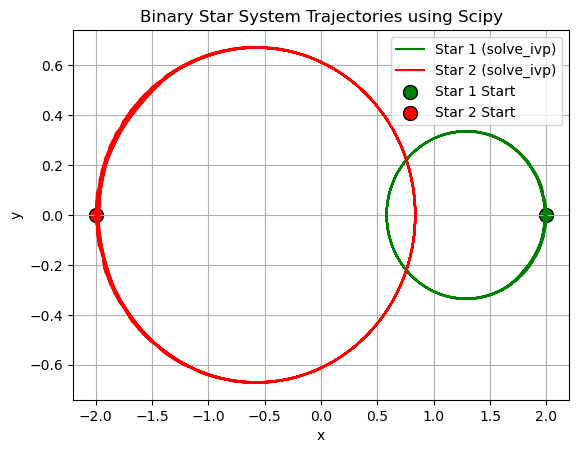

In [4]:
#StarSystem class
class StarSystem:
    """
    Class to represent a binary star system.

    Attributes:
    - stars (list): A list containing Star objects, representing the binary star system.

    Methods:
    - compute_derivatives : Calculates the derivatives of position and velocity for integration purposes.
    - integrate_solve_ivp: Numerical integration using scipy's solve_ivp method.
    - integrate_midpoint: Numerical integration using the Midpoint method.
    - plot_phase_plot_star1.
    
    """

    def __init__(self, star1, star2):
        self.star1 = star1
        self.star2 = star2 
        self.G = 1 # Gravitational constant
        
        total_momentum = star1.mass * star1.velocity + star2.mass * star2.velocity
        assert np.allclose(total_momentum, 0), "Initial momentum is not zero."


    def compute_derivatives(self, t, y):
        """Compute derivatives for integration."""
        
        x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y
        position1 = np.array([x1, y1])
        position2 = np.array([x2, y2])
        
        # Calculate distances and accelerations
        r_vector = position2 - position1 # r is the radius given in the orignal ODE
        r = np.linalg.norm(r_vector)
        
        if r == 0:
            raise ValueError("Stars overlap, causing division by zero in gravitational calculation.")
            
        acceleration1 = self.G * self.star2.mass * r_vector / r**3
        acceleration2 = -self.G * self.star1.mass * r_vector / r**3
        
        return [vx1, vy1, vx2, vy2, acceleration1[0], acceleration1[1], acceleration2[0], acceleration2[1]]

    def integrate_solve_ivp(self, t_span, y0, rtol=1e-5):
        """Numerical integration using solve_ivp (RK45)."""
        return solve_ivp(self.compute_derivatives, t_span, y0, method='RK45', rtol=rtol)

    def integrate_midpoint(self, y0, dt, t_span):
        """Midpoint method integration."""
        t = t_span[0]  #t t for time 
        y = np.array(y0, dtype=float)
        results = [[t, *y]]
        while t < t_span[1]:
            # Midpoint calculation
            k1 = np.array(self.compute_derivatives(t, y))
            y_mid = y + 0.5 * dt * k1 # y_mid is the estimated midpoint
            k2 = np.array(self.compute_derivatives(t + 0.5 * dt, y_mid))
            y += dt * k2 # k2 is the rate of change at the midpoint
            t += dt # dt is the time step 
            results.append([t, *y])
        return np.array(results)
    

    def plot_phase_plot_star1(self, a_linestyle='-'):
        """Plots the phase plot for Star 1 (y1 vs vy1)."""
        assert self._solution_solved, "Solution has not yet been found."
        
        # Extract y1 (position of star1) and vy1 (velocity of star1)
        y1 = self._solution_y[1]  # y1 position
        vy1 = self._solution_y[5]  # vy1 velocity
        
        plt.figure()
        plt.plot(y1, vy1, a_linestyle)
        plt.grid()
        plt.xlabel("y Position of Star 1", fontsize=14)
        plt.ylabel("y Velocity of Star 1 (vy1)", fontsize=14)
        plt.title("Phase Plot for Star 1")
        plt.show()
        
# Initial conditions for integration
y0 = [*star1.position, *star2.position, *star1.velocity, *star2.velocity]
t_span = (0, 100)

# Create the star system and integrate
system = StarSystem(star1, star2)

# Using solve_ivp
solution_ivp = system.integrate_solve_ivp(t_span, y0)

# Using midpoint method
dt = 0.01
sol_midpoint = system.integrate_midpoint(y0, dt, t_span)

# Plot trajectories
plt.figure()
plt.plot(solution_ivp.y[0], solution_ivp.y[1], label="Star 1 (solve_ivp)", color='green')
plt.plot(solution_ivp.y[2], solution_ivp.y[3], label="Star 2 (solve_ivp)", color='red')

# Add blobs for the initial positions of Star 1 and Star 2
plt.scatter(solution_ivp.y[0][0], solution_ivp.y[1][0], color='green', marker='o', s=100, edgecolor='black', label="Star 1 Start")
plt.scatter(solution_ivp.y[2][0], solution_ivp.y[3][0], color='red', marker='o', s=100, edgecolor='black', label="Star 2 Start")

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Binary Star System Trajectories using Scipy')
plt.grid()
plt.show()

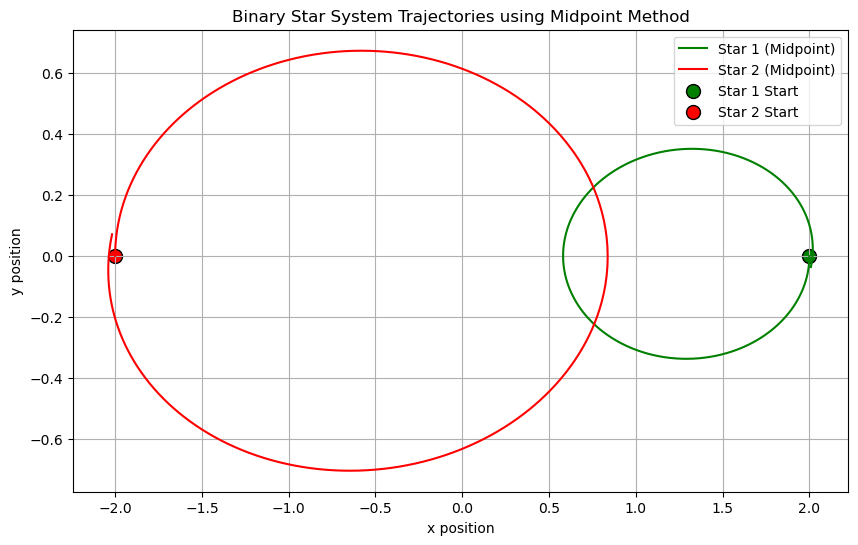

In [5]:
# Initial conditions for the stars
M1 = 2.0
M2 = 1.0
position1 = [2.0, 0.0]
velocity1 = [0.0, -0.1]
position2 = [-2.0, 0.0]
velocity2 = [-velocity1[0] * M1 / M2, -velocity1[1] * M1 / M2]  # Conservation of momentum

# Create instances of Star
star1 = Stars(M1, position1, velocity1)
star2 = Stars(M2, position2, velocity2)

# Create StarSystem
system = StarSystem(star1, star2)

# Initial conditions for integration
y0 = [*star1.position, *star2.position, *star1.velocity, *star2.velocity]
time_span = (0, 12)

# Integrate using Midpoint Method
dt = 0.01
solution_midpoint = system.integrate_midpoint(y0, dt, time_span)

# Plot trajectories of the stars using Midpoint Method
plt.figure(figsize=(10, 6))
plt.plot(solution_midpoint[:, 1], solution_midpoint[:, 2], label="Star 1 (Midpoint)", color='green')
plt.plot(solution_midpoint[:, 3], solution_midpoint[:, 4], label="Star 2 (Midpoint)", color='red')


# Add blobs for the initial positions of Star 1 and Star 2
plt.scatter(solution_ivp.y[0][0], solution_ivp.y[1][0], color='green', marker='o', s=100, edgecolor='black', label="Star 1 Start")
plt.scatter(solution_ivp.y[2][0], solution_ivp.y[3][0], color='red', marker='o', s=100, edgecolor='black', label="Star 2 Start")


plt.xlabel('x position')
plt.ylabel('y position')
plt.legend()
plt.title('Binary Star System Trajectories using Midpoint Method')
plt.grid()
plt.show()

#### Binary System Trajectories : ####

##### 1- Scipy's solve_ivp() Method : #####
The Binary Star System Trajectories graph shows that:

    When the stars are close together, they move faster. The gravitational 
    pull between them is stronger at this point, causing a rapid change in position, which translates into a higher velocity.

    However when the stars are far apart, they move more slowly. The gravitational pull is weaker at greater distances, so the stars decelerate, resulting in a slower rate of positional change.

The stars are shown in stable, balanced orbits, where the closed loops of both trajectories indicate that the system is in a stable configuration. Each star moves at a velocity that keeps it in a consistent distance from the other, neither escaping nor collapsing inward.




##### 2- Midpoint Method : #####
Above is a trajectory plot for star 1 and star 2 using the midpoint method.

The general shape of the orbits is similar to that of solve_ivp(), indicating that the midpoint method is capturing the essential behavior of the system correctly.

The curves show slightly less smoothness compared to solve_ivp(), which is typical of a simpler numerical integration methods.

The midpoint method provides an approximation that is less accurate than solve_ivp(), which can lead to accumulated errors over time.



In general we notice the following:

    1- Both methods give similar shapes for the orbits, indicating that both methods are capturing the gravitational dynamics correctly.

    2- The midpoint method is a simpler approach, and although it captures the key dynamics, its solution might be less accurate, particularly in longer time simulations where errors accumulate.
    
    3- For short to moderate time spans, both solve_ivp() and the midpoint method can be used effectively, with solve_ivp() providing a more accurate result.
    
    4- For high-precision requirements or longer-term simulations, solve_ivp() is preferable due to its adaptive step size 
    and improved numerical stability.

We'll plot the phase diagram for one of the stars, I decided to go for Star 1.

#### What am I expecting to see in the phase diagram ? ####

In the phase diagram for a binary star system, I expect to see a closed, elliptical loop that reflects the periodic motion of the Star1. This loop indicates that Star1's velocity increases as it moves closer to Star2 (due to stronger gravitational attraction) and decreases as it moves further away.


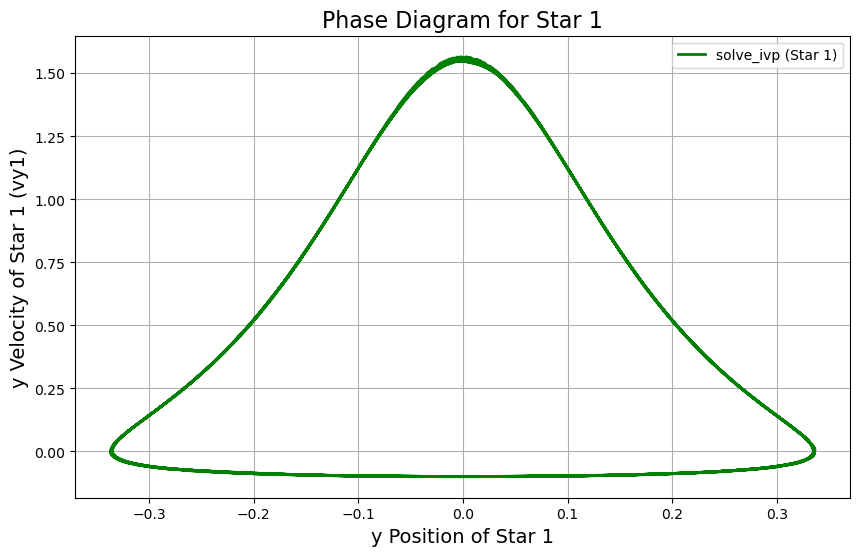

In [5]:
# Extracting data for Star 1 from solve_ivp 

y1_ivp = solution_ivp.y[1]  # y position of Star 1 from solve_ivp
vy1_ivp = solution_ivp.y[5]  # vy velocity of Star 1 from solve_ivp

# Plot the phase diagram for Star 1
plt.figure(figsize=(10, 6))

# Phase diagram using solve_ivp
plt.plot(y1_ivp, vy1_ivp, 'g-', label='solve_ivp (Star 1)', linewidth=2)

# Labels and title
plt.xlabel('y Position of Star 1', fontsize=14)
plt.ylabel('y Velocity of Star 1 (vy1)', fontsize=14)
plt.title('Phase Diagram for Star 1', fontsize=16)
plt.legend()
plt.grid()
plt.show()


#### Phase diagram for Star 1 analysis : ####
The phase diagram represents the y position of Star 1 versus its y velocity, the diagram forms a **smooth closed curve**, which suggests that Star 1 is in a stable orbit (following a periodic motion) around Star 2 in a binary system. 

Since the path is a closed loop, it indicates that Star 1 keeps repeating the same pattern of motion. This is expected for a stable gravitational system like a binary star, where each star follows a predictable, repeating orbit.

The shape of the phase plot is not a perfect circle but resembles a rounded triangular-like loop, the rounded shape suggests that the velocity reaches a maximum value when Star 1 is within a certain distance from Star 2, and then decreases when the stars move further away.

#### Midpoint Vs Euler methods : ####
Two reasons why it is better to use the midpoint method over Euler's method are:

    1- Higher Accuracy: 
    
    The midpoint method is generally more accurate than Euler's method for the same step size because it uses information 
    from the midpoint of the interval to estimate the next value, reducing truncation errors. 
    
    The midpoint method is a second order method whereas Euler's method is a first order method. The midpoint method converges faster than Euler's method.

    2- Stability:
    
    The midpoint method is more stable than Euler's method, particularly for stiff equations or systems with rapid oscillations, allowing for larger time steps without losing accuracy.
    
The midpoint method is stable, has 2nd order global truncation error, whereas Euler is unstable and 1st order.


### Convergence testing : ###
Next we need to set up a convergence test for the midpoint method to confirm that the solution converges at the required order.

To do this I used a code from Week4Lab_exercises: Activity 2 to test for the convergence of the midpoint method:

##### Convergence Test Explanation ####
   

In this convergence test, we aim to verify the second-order convergence of the midpoint method used to integrate the equations of motion for a binary star system. We compare the y coordinates at three different resolutions to see if the error scales as expected.



We integrate the system using three different step sizes, defined by the number of steps \( N \in \{16, 32, 64\} \), where:

\begin{equation}
h = \frac{t_{\text{end}} - t_{\text{start}}}{N}
\end{equation}

The midpoint method is a second-order accurate method, meaning that if we halve the step size, the error should reduce by approximately a factor of 4 


The convergence condition we are testing is:

\begin{equation}
\frac{\lVert y_{N=64} - y_{N=32} \rVert}{\lVert y_{N=32} - y_{N=16} \rVert} \approx \frac{1}{4}
\end{equation}



If the error reduction between successive resolutions has a  scaling factor of approximately 1/4, then we can conclude that the midpoint method is converging with the expected second-order accuracy, and thus we are "In the convergence regime".

Here is what I am trying to do to prove that the midpoint method is within the converegenve regime:

**Step 1 :**

Define 3 different step sizes and since we do not know the solutions we use 3 resolutions to test convergence .
    
**Step 2 :**

We find the High-Resolution (HR) difference, defined as y3-y2, and the Low-Resolution (LR) difference, defined as y2-y1.

**Step 3 :**

The differences LR and HR are plotted, we are expecting the plot to show that the solution converges as the step size decreases, as the step size decreases the difference between two consecutive solutions also decreases, and the differences should scale by a factor of 4.

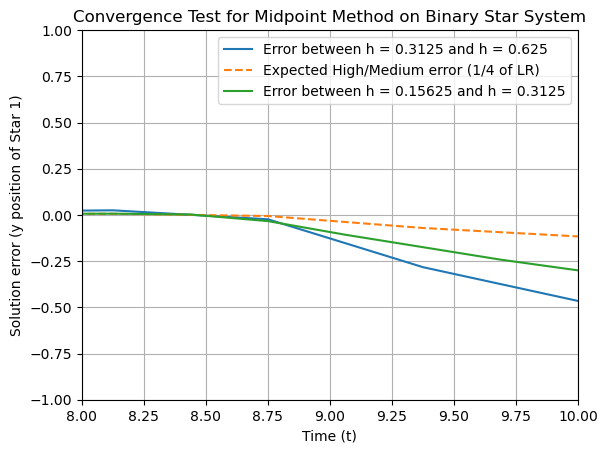

In [6]:
# Test the integrator for the midpoint method - error should decrease 
# by factor of 4 as it is second order

# Create the two stars for the binary system
star1 = Stars(1.0, [2.0, 0.0], [0.0, -0.1])
star2 = Stars(0.5, [-2.0, 0.0], [0.0, 0.2])

# Create the star system
system = StarSystem(star1, star2)

# Initial conditions for integration
y0 = [*star1.position, *star2.position, *star1.velocity, *star2.velocity]
t_span = (0, 10)

# Midpoint convergence test: error should decrease by a factor of 4 as it is second order
order = 2.0 ** 2.0  # Midpoint method is second-order, hence error reduction factor is 4

# Define different step sizes by adjusting the number of steps
N_steps_vector = [16, 32, 64]

# Store the old solution to compare with new solution
old_solution = None

# Perform convergence test for the midpoint method
for isteps, N_steps in enumerate(N_steps_vector):
    # Time step for the current iteration
    dt = (t_span[1] - t_span[0]) / N_steps
    
    # Integrate using the midpoint method
    solution_midpoint = system.integrate_midpoint(y0, dt, t_span)
    
    # Extract time and y positions of Star 1 for each resolution
    t_values = solution_midpoint[:, 0]
    y_values = solution_midpoint[:, 3]  # y position of Star 1 (index 3 for y1)
    
    if isteps > 0:
        # Compare current solution with previous (coarser) solution
        # Downsample the finer solution to match the length of the coarser solution
        y_values_reduced = y_values[::2]
        diff = y_values_reduced - old_solution

        # Plot the error between consecutive solutions
        plt.plot(t_values[::2], diff,
                 label=f"Error between h = {dt} and h = {dt * 2}")
        
        # Plot expected error reduction for convergence test
        if isteps == 1:
            plt.plot(t_values[::2], diff / order, '--',
                     label="Expected High/Medium error (1/4 of LR)")
    
    # Store the current solution as the old solution for the next iteration
    old_solution = y_values

# Plot configuration
plt.grid()
plt.legend()
plt.ylabel("Solution error (y position of Star 1)")
plt.xlabel("Time (t)")
plt.ylim(-1, 1)
plt.xlim(8, 10)
plt.title("Convergence Test for Midpoint Method on Binary Star System")
plt.show()


#### Interpretation :

The green line is below the blue line, this indicates that the error decreases as the resolution is increased,the red dashed line, is 1/4 of the LR difference, this shows that the midpoint method is working properly. So I can improve my test by  reducing the step size. 

I was expecting to see two lines where the error is x4 reduced because if we double the resolution, we know that the difference should scale as 1/4, but I am not sure how to fix the code to obtain the results I hoped for. 

### 3.2 Problem 2: Triple system  (35% of marks)

Model a three body system made up of 3 stars with equal masses. Stars are assumed to be point like objects and so they cannot collide or merge with each other (they simply pass through each other if found at the same location at the same time).

**2a) A stable 3 body system**

First model the stable solution discovered by Cris Moore and proved by Chenciner and Montgomery, described [here](https://arxiv.org/abs/math/0011268). 

_(HINT 1: Note that the authors use complex numbers to describe the positions and velocities, so a position of $1 + 3i$ means $[x,y] = [1,3]$)_

**Required Components**

1. You should use or extend your classes from problem 1

2. Provide plots of the trajectories for all stars and a phase diagram for the position and velocity of one of the component stars

3. Compare two explicit integration techniques - the first should be scipy's solve_ivp() and the second should be the midpoint method (or another Runge Kutta method of specified order)

4. For the midpoint/Runge Kutta method, provide a convergence test confirming that the solution converges at the required order

5. Include defensive programming techniques such as asserts and tests of key functionality

6. Provide some documentation of the code implemented in markdown

## The Three-Body System Model ##

### 3.2 Problem 2: Triple system : ###

The research paper is about a stable solution to the three-body problem, known as the figure-eight orbit, discovered by Cris Moore and proved by Chenciner and Montgomery.

#### A quick summary of the research paper : ####

In the classical three-body problem, three objects move under their mutual gravitational attraction, which often leads to chaotic and unpredictable orbits. However, this paper presents a specific, stable solution where three equal-mass bodies move in a symmetrical, repeating figure-eight pattern. This solution is remarkable because it is periodic (the stars repeat their positions and velocities after a certain period) and stable in a mathematical sense, meaning the stars do not collide or fly apart over time.

The paper also discusses the symmetry and complex geometry of the figure-eight orbit, providing the precise initial conditions and velocities required to achieve this rare stable configuration, and these are the initial conditions I will be using to achieve the infinity like, **figure-eight orbit**.
This works for a system where:

1. The masses are equal.
2. The positions are set so the stars start spaced equally around a central point.
3. The velocities are such that each star will follow the figure-eight path without deviating over time.

#### A stable 3 body system : #####

This code models a stable three-body system with equal masses, all pulling on each other with gravity. Instead of just orbiting in simple circles or ellipses, these stars follow a special, stable path discovered by Cris Moore and proved by Chenciner and Montgomery.
A three-body system is a group of three stars that are all attracted to each other by gravity. This attraction makes their paths more complex and unpredictable than two-body systems, like a planet orbiting a single star.

The required classes are `Stars` and `ThreeBodySystem` : Representing the entire three-body system, managing the interactions between the stars and calculating forces and accelerations.

The aim is to satisfy the following points:

  1. A code that calculates where each star moves over time by computing how the gravitational pull from each star affects the others.
  
  2. The stars are set up in a unique way so they move in a stable figure-eight pattern, meaning they repeat the same path over and over without crashing into each other or drifting away.
  
  3. The code should have two different techniques to calculate the stars' paths:
      - A standard method `scipy's solve_ivp`.
      - and the `midpoint method` to show how different methods affect the results.
      
      
  4. Lastly we set up a convergence test to check if the midpoint method is reliable by seeing how its accuracy improves when we use smaller time steps.


I was aiming to use the exact compute_derivatives method from StarSystem but for some reason I kept getting an error message (saying too many values to unpack, I had some hard time trying to fix that) hence why I decided to change my method `compute_derivatives` to save me some time.

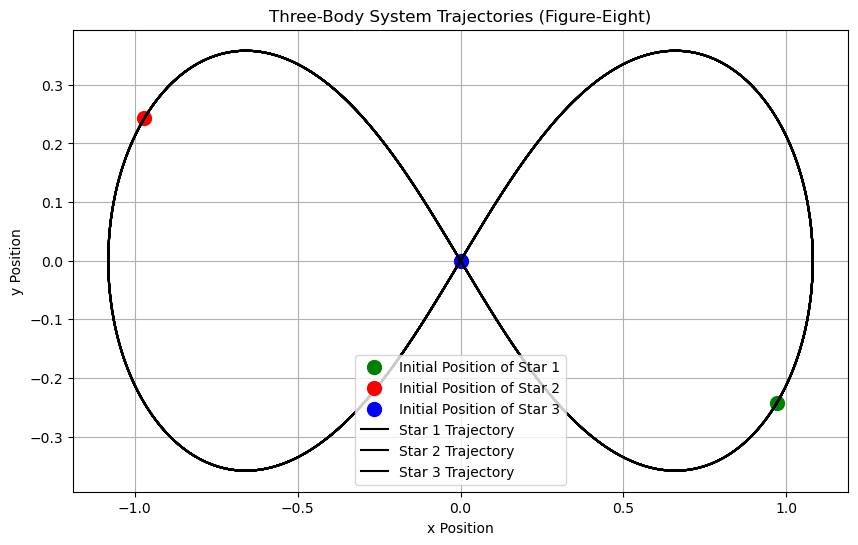

In [7]:
# ThreeBodySystem class 

class ThreeBodySystem:
    """
    Class to represent a three-body gravitational system.

    Attributes:
    - stars (list): A list containing Star objects, representing the three stars in the system.

    Methods:
    - compute_derivatives: Calculates the derivatives of position and velocity for integration.
    - integrate_solve_ivp: Numerical integration using scipy's solve_ivp method (RK45).
    - integrate_midpoint: Numerical integration using the midpoint method.
    - plot trajectories
    - plot phase diagram.
    """
    #Constructor function:
    
    def __init__(self, stars):
        if len(stars) != 3:
            raise ValueError("ThreeBodySystem must contain exactly three stars")
        self.stars = stars
        self.G = 1  # Gravitational constant

    def compute_derivatives(self, t, y):
        n = len(self.stars)
        positions = y[:2 * n].reshape((n, 2))
        velocities = y[2 * n:].reshape((n, 2))
        accelerations = np.zeros((n, 2))

        # Compute accelerations for each star
        for i in range(n):
            for j in range(n):
                if i != j:
                    r_vec = positions[j] - positions[i]
                    r = np.linalg.norm(r_vec)
                    if r != 0:
                        accelerations[i] += self.G * self.stars[j].mass * r_vec / r**3

        
        derivatives = np.concatenate([velocities.flatten(), accelerations.flatten()])
        return derivatives
    
    def integrate_orbits(self, y0, t_span, method='RK45', rtol=1e-9, atol=1e-12, t_eval=None):
        """Numerical integration of the system's orbits using solve_ivp."""
        return solve_ivp(self.compute_derivatives, t_span, y0, method=method, rtol=rtol, atol=atol, t_eval=t_eval)
    
    def integrate_midpoint(self, y0, dt, t_span):
        """Midpoint method integration."""
        t = t_span[0] #t t for time 
        y = np.array(y0, dtype=float)
        results = [[t, *y]]
        while t < t_span[1]:
            # Midpoint calculation
            k1 = np.array(self.compute_derivatives(t, y)) * dt
            y_mid = y + 0.5 * k1 # ymid is the estimated midpoint
            k2 = np.array(self.compute_derivatives(t + 0.5 * dt, y_mid)) * dt
            y += k2 # k2 is the rate of change at the midpoint
            t += dt # dt is the time step
            results.append([t, *y])
        return np.array(results)
    
    def integrate_rk4(self, y0, t_span, dt):
        """Numerical integration of the system's orbits using the 4th-order Runge-Kutta (RK4) method."""
        t = t_span[0]
        t_values = [t]
        y_values = [np.array(y0)]

        while t < t_span[1]:
            y = y_values[-1]
            k1 = np.array(self.compute_derivatives(t, y))
            k2 = np.array(self.compute_derivatives(t + 0.5 * dt, y + 0.5 * dt * k1))
            k3 = np.array(self.compute_derivatives(t + 0.5 * dt, y + 0.5 * dt * k2))
            k4 = np.array(self.compute_derivatives(t + dt, y + dt * k3))
            y_next = y + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

            t += dt
            t_values.append(t)
            y_values.append(y_next)

        return np.array(t_values), np.array(y_values)
    
    def plot_trajectories(self, solution, n=3):
        plt.figure(figsize=(10, 6))
        
        # Plot the initial positions of the stars
        plt.plot(solution.y[0, 0], solution.y[1, 0], 'o', color='green', markersize=10, label='Initial Position of Star 1')
        plt.plot(solution.y[2, 0], solution.y[3, 0], 'o', color='red', markersize=10, label='Initial Position of Star 2')
        plt.plot(solution.y[4, 0], solution.y[5, 0], 'o', color='blue', markersize=10, label='Initial Position of Star 3')
        
        # Plot trajectories of stars
        for i in range(n):
            plt.plot(solution.y[2 * i], solution.y[2 * i + 1], color='black', label=f"Star {i + 1} Trajectory")
        
        plt.xlabel('x Position')
        plt.ylabel('y Position')
        plt.title('Three-Body System Trajectories (Figure-Eight)')
        plt.legend()
        plt.grid()
        plt.show()

    def plot_phase_diagram(self, solution, star_index=0):
        plt.figure(figsize=(10, 6))
        plt.plot(solution.y[2 * star_index], solution.y[2 * star_index + 2], label=f"Phase Diagram of Star {star_index + 1}")
        plt.xlabel('x Position')
        plt.ylabel('x Velocity')
        plt.legend()
        plt.grid()
        plt.show()

# Using initial conditions from the paper (Chenciner & Montgomery)
star1 = Stars(1.0, [0.97000436, -0.24308753], [0.466203685, 0.43236573])
star2 = Stars(1.0, [-0.97000436, 0.24308753], [0.466203685, 0.43236573])
star3 = Stars(1.0, [0.0, 0.0], [-0.93240737, -0.86473146])

# Create three-body system
three_body_system = ThreeBodySystem([star1, star2, star3])
y0_three_body = [*star1.position, *star2.position, *star3.position, *star1.velocity, *star2.velocity, *star3.velocity]
t_span_three_body = (0, 20)

# Integrate using solve_ivp
solution_ivp_three_body = three_body_system.integrate_orbits(y0_three_body, t_span_three_body, method='RK45')

# Plot the trajectories for the solve_ivp solution
three_body_system.plot_trajectories(solution_ivp_three_body)

The Figure_Eight plot shows the trajectories of the three stars. These trajectories appear to follow a stable figure-eight pattern.
The figure-eight solution is a rare but known stable configuration for three gravitationally interacting bodies. This pattern indicates that each star’s gravitational pull balances out the others in such a way that they all follow stable, periodic orbits without collision or ejection. 

In part 2b of this crousework, we will see that when I pertube the velocity I end up getting a chaotic and unstable system, demonstrating how sensitive the Figure-eight intial conditions are.


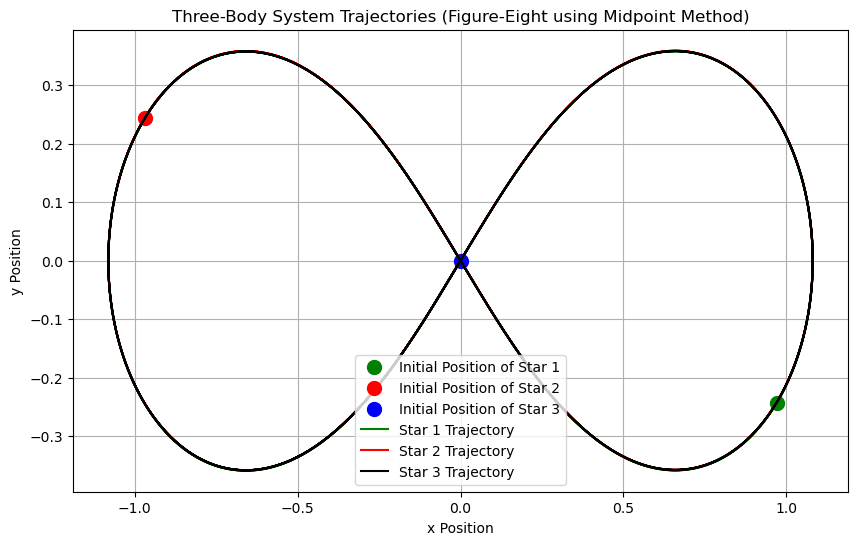

In [8]:
#Trajectories of the stable three body system using the midpoint method
star1 = Stars(1.0, [0.97000436, -0.24308753], [0.466203685, 0.43236573])
star2 = Stars(1.0, [-0.97000436, 0.24308753], [0.466203685, 0.43236573])
star3 = Stars(1.0, [0.0, 0.0], [-0.93240737, -0.86473146])

# Create three-body system
three_body_system = ThreeBodySystem([star1, star2, star3])

# Initial conditions (positions and velocities)
y0_three_body = [
    *star1.position, *star2.position, *star3.position,
    *star1.velocity, *star2.velocity, *star3.velocity
]
t_span_three_body = (0, 20)
dt = 0.01  # Time step for midpoint integration

# Integrate using midpoint method
solution_midpoint_three_body = three_body_system.integrate_midpoint(y0_three_body, dt, t_span_three_body)

# Plot the trajectories for the midpoint solution
def plot_trajectories_midpoint(solution):
    plt.figure(figsize=(10, 6))

    # Extract the time and the solution values
    time = solution[:, 0]
    y_values = solution[:, 1:]
    

    # Plot the initial positions of the stars
    plt.plot(y_values[0, 0], y_values[0, 1], 'o', color='green', markersize=10, label='Initial Position of Star 1')
    plt.plot(y_values[0, 2], y_values[0, 3], 'o', color='red', markersize=10, label='Initial Position of Star 2')
    plt.plot(y_values[0, 4], y_values[0, 5], 'o', color='blue', markersize=10, label='Initial Position of Star 3')

    # Plot trajectories of stars
    plt.plot(y_values[:, 0], y_values[:, 1], color='green', label='Star 1 Trajectory')
    plt.plot(y_values[:, 2], y_values[:, 3], color='red', label='Star 2 Trajectory')
    plt.plot(y_values[:, 4], y_values[:, 5], color='black', label='Star 3 Trajectory')

    plt.xlabel('x Position')
    plt.ylabel('y Position')
    plt.title('Three-Body System Trajectories (Figure-Eight using Midpoint Method)')
    plt.legend()
    plt.grid()
    plt.show()

# Plot the figure-eight trajectories
plot_trajectories_midpoint(solution_midpoint_three_body)


#### Interpretation of the plots : ####

Both figures show that the three stars follow a closed figure-eight trajectory. This means that the stars consistently repeat their orbits in this exact pattern.The fact that both integration methods yield similar results suggests that both are effective at capturing the fundamental gravitational dynamics governing this three-body system.

The trajectory of each star is perfectly symmetrical about the origin, and the stars move in a way that preserves the system's center of mass. This symmetry indicates that the forces between the stars are balanced in such a way that each star's motion is counteracted by the gravitational pull of the other two. The trajectories all cross at the same point in the center, showing that the interactions between the stars are well-coordinated and that the system remains stable over time.

While both methods produce very similar results, the solve_ivp() method is generally more accurate, particularly over longer periods. It uses adaptive step sizes.

The midpoint method, on the other hand, uses fixed time steps and is simpler but can introduce more numerical error over long simulations.

From the plots, the trajectories generated by the midpoint method may exhibit slight deviations from the solve_ivp() results if examined over a longer timescale. 


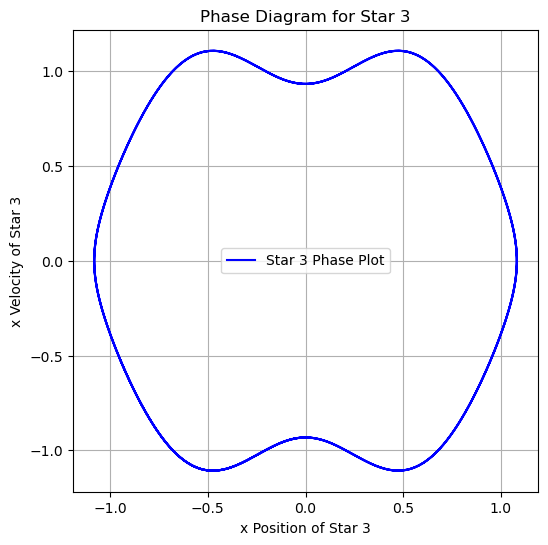

In [9]:
def plot_phase_diagram_star3(solution):
    plt.figure(figsize=(6, 6))

    # Extract x position and x velocity of Star 3
    y_values = solution[:, 1:]
    x_position_star3 = y_values[:, 4]  # x position of Star 3
    x_velocity_star3 = y_values[:, 10]  # x velocity of Star 3

    # Plot the phase diagram
    plt.plot(x_position_star3, x_velocity_star3, color='blue', label='Star 3 Phase Plot')

    plt.xlabel('x Position of Star 3')
    plt.ylabel('x Velocity of Star 3')
    plt.title('Phase Diagram for Star 3')
    plt.legend()
    plt.grid()
    plt.show()

# Plot the phase diagram for Star 3
plot_phase_diagram_star3(solution_midpoint_three_body)

The phase plot shows the relationship between the x position and x velocity of Star 3 over time.

The closed loop in the phase plot indicates periodic motion, meaning Star 3 repeats the same movement over time.

The closed loop also shows a stable, repeating orbit with an intricate balance of gravitational forces between the three stars.

The plot is symmetric about both axes, suggesting consistent periodic movement where Star 3 passes through similar regions of space with equal speed in opposite directions.

The three stars, with equal mass, follow a figure-eight trajectory in a symmetrical and periodic manner, causing them to speed up and slow down repeatedly.

The curved shape results from gravitational interactions, with Star 3 accelerating when closer to the other stars and decelerating as it moves further away.

Bumps in the phase diagram indicate significant changes in velocity:

    - Peaks represent the maximum speed of the star in the positive or negative direction.
    
    - The shape of the curve reflects gravitational forces causing Star 3 to speed up when closer and slow down when further away.
    

#### Comparing scipy's solve_ivp() and the midpoint method : ####
**Midpoint Method**:
- A second-order Runge-Kutta method, meaning it achieves second-order accuracy.
- Uses an intermediate step to improve accuracy over Euler’s method.
- More stable than Euler’s method, as it uses an intermediate point, reducing the effect of errors.
- Uses a fixed step size; thus, convergence can only be improved by manually decreasing the step size.
- Convergence test: If we halve the step size ℎ, the global error should roughly decrease by 1/4.

**RK45 in `solve_ivp`**:
- A more complex Runge-Kutta method that combines fourth and fifth-order steps, a  4th order Runge Kutta solver, with a 5th order Runge Kutta method to check the numerical error at each step.
- Automatically adjusts the step size based on error tolerance (controlled by `rtol` and `atol`).
- Achieves fourth or fifth-order global accuracy, making it more precise for smaller step sizes
- Adapts the step size automatically to maintain error within specified tolerances.
- For convergence, setting rtol to a lower value increases accuracy.

The midpoint method is tested for second-order accuracy, the same convergence test I used for the midpoint method for the binary star system can be used here.

Alternartively we can carry out a convergence test for the rk4 method, simply by following the code in week4_labexercises and tweaking it to satisfy this problem.

Test the integrator for the RK4 method - error should decrease by factor of 16 as it is 4th order.

Below is the code I am referring to :


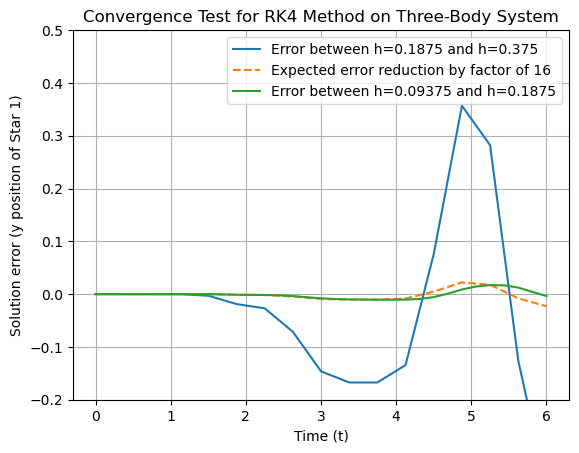

In [10]:
# Test the integrator for the RK4 method - error should decrease 
# by factor of 16 as it is 4th order

 
star1 = Stars(1.0, [0.97000436, -0.24308753], [0.466203685, 0.43236573])
star2 = Stars(1.0, [-0.97000436, 0.24308753], [0.466203685, 0.43236573])
star3 = Stars(1.0, [0.0, 0.0], [-0.93240737, -0.86473146])

three_body_system = ThreeBodySystem([star1, star2, star3])

# Initial conditions vector for the three stars
y0_three_body = [*star1.position, *star2.position, *star3.position,
                 *star1.velocity, *star2.velocity, *star3.velocity]

# Time span for integration
t_span_three_body = (0, 6)

# Step sizes for the convergence test : these are the three resolutions 
N_steps_vector = [16, 32, 64]
order = 2.0 ** 4.0  

# Store old solution to compare with new solution
old_solution = None


# Perform convergence test for RK4
for isteps, N_steps in enumerate(N_steps_vector):
    # Time step for current iteration
    dt = (t_span_three_body[1] - t_span_three_body[0]) / N_steps
    
    # Integrate using RK4
    t_values, y_values = three_body_system.integrate_rk4(y0_three_body, t_span_three_body, dt)
    
    # Extract y positions of Star 1 for each resolution
    y_position_star1 = y_values[:, 1]  # y position of Star 1 is at index 1
    
    if isteps > 0:
        # Compare current solution with previous solution
       
        y_position_star1_reduced = y_position_star1[::2]
        diff = y_position_star1_reduced - old_solution

        # Plot the error between consecutive solutions
        plt.plot(t_values[::2], diff,
                 label=f"Error between h={dt} and h={dt*2}")
        
        # Plot expected error reduction for convergence test
        if isteps == 1:
            plt.plot(t_values[::2], diff / order, '--',
                     label="Expected error reduction by factor of 16")
    
    # Store current solution as the old solution for the next iteration
    old_solution = y_position_star1

# Plot configuration
plt.grid()
plt.legend()
plt.ylabel("Solution error (y position of Star 1)")
plt.xlabel("Time (t)") 
plt.title("Convergence Test for RK4 Method on Three-Body System")
plt.ylim(-0.2, 0.5)
plt.show()




The orange dashed line `Expected error reduction by factor of 16` represents the expected behavior for the convergence of the RK4 method, which is a 4th-order method. This means that the error should reduce by approximately a factor of 16 as the time step is halved.

The RK4 is a **fourth-order** accuracy method, since the error of the ratio is 1/16. Thus we are **in the convergence regime**.

**2b) A chaotic 3 body system**

Now model one in which the stars display chaotic behaviour, with one star being ejected from the system.

1. Provide plots of the trajectories of all the stars and a phase diagram for the position and velocity of one of the component stars, and explain how and why the phase plot differs from the stable system above

2. Include defensive programming techniques such as asserts and tests of key functionality

3. Provide some documentation of the code implemented in markdown

_(HINT: For the initial conditions, you could start with the stable values and gradually change them until the system becomes unstable.)_

#### The chaotic three body system : ####

This 3 body system is `chaotic` meaning the movement of the stars is unpredictable and one of the stars may get ejected from the system due to the gravitational forces.



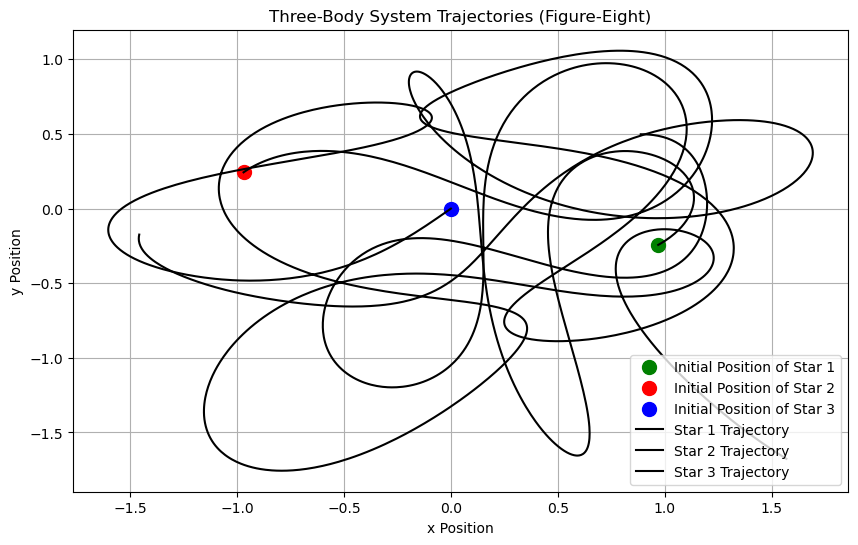

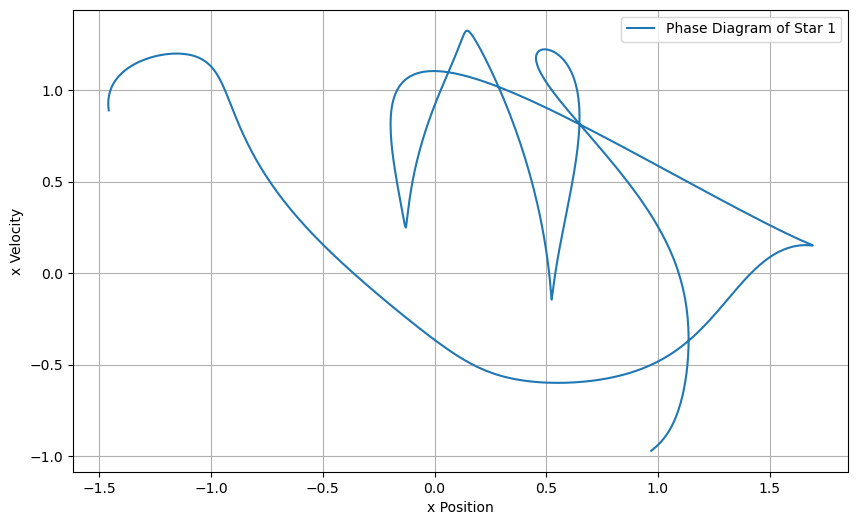

In [11]:
# Modify initial conditions to induce chaos (slight changes to stable initial conditions)
star1 = Stars(1.0, [0.97000436, -0.24308753], [0.55, 0.43236573])  
star2 = Stars(1.0, [-0.97000436, 0.24308753], [0.5, 0.5])           
star3 = Stars(1.0, [0.0, 0.0], [-1.0, -1.0])                

#[-1.05, -0.86473146]

# Create three-body system with the chaotic initial conditions
three_body_system_chaotic = ThreeBodySystem([star1, star2, star3])
y0_chaotic = [*star1.position, *star2.position, *star3.position, *star1.velocity, *star2.velocity, *star3.velocity]
t_span_chaotic = (0, 20)

# Integrate using solve_ivp for chaotic system
solution_ivp_chaotic = three_body_system_chaotic.integrate_orbits(y0_chaotic, t_span_chaotic, method='RK45')

# Plot the trajectories for the chaotic solve_ivp solution
three_body_system_chaotic.plot_trajectories(solution_ivp_chaotic)

# Plot the phase diagram for one of the stars (Star 1)
three_body_system_chaotic.plot_phase_diagram(solution_ivp_chaotic, star_index=0)


#### Interpretation : ####
##### Trajectories #####
The stars cross paths frequently, and the trajectories appear complex and unpredictable, lacking stability.

The motion is much more disordered, and we can see instances where the stars seem to be pulling away from each other, eventually diverging in an uncontrolled manner.

In chaotic three-body systems, there is often a point where one star gains enough momentum to be effectively ejected from the system, this is shown in the figure below.

In the stable system, the stars move in a symmetric and repeating path, maintaining a clear, periodic figure-eight structure.

In this plot, there is no symmetry or repeating pattern; the stars do not maintain their initial orderly relationship. This indicates that the gravitational forces are acting in a manner that disrupts stability, leading to unpredictable and non-periodic paths.

##### Phase plot #####

In the stable system, the phase diagram is a closed loop, indicating periodic motion. The relationship between velocity and position is stable and predictable.

In the chaotic system, the phase diagram is complex and non-repeating, showing that the star does not return to previous positions and velocities in a regular manner. This indicates the system has entered a chaotic regime, where the gravitational interactions are no longer balanced.

The chaotic nature of the system is caused by the sensitivity to initial conditions. Even a small perturbation can lead to vastly different outcomes.

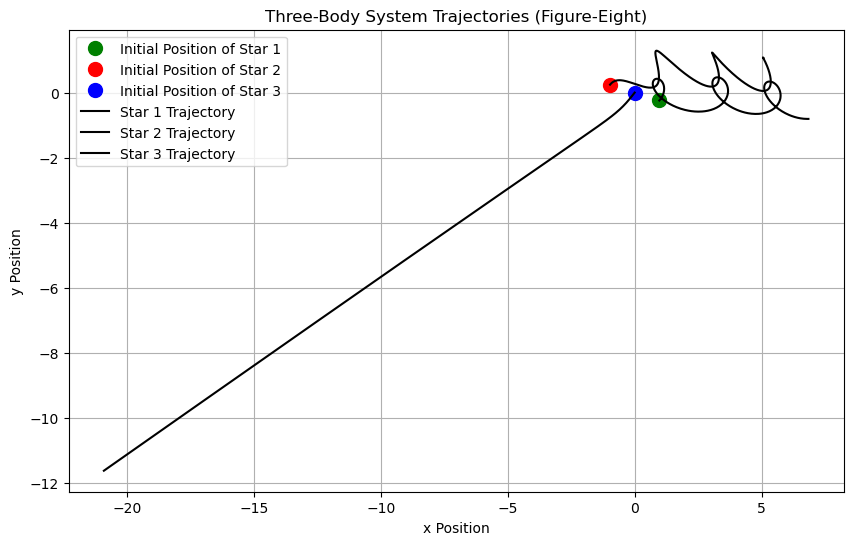

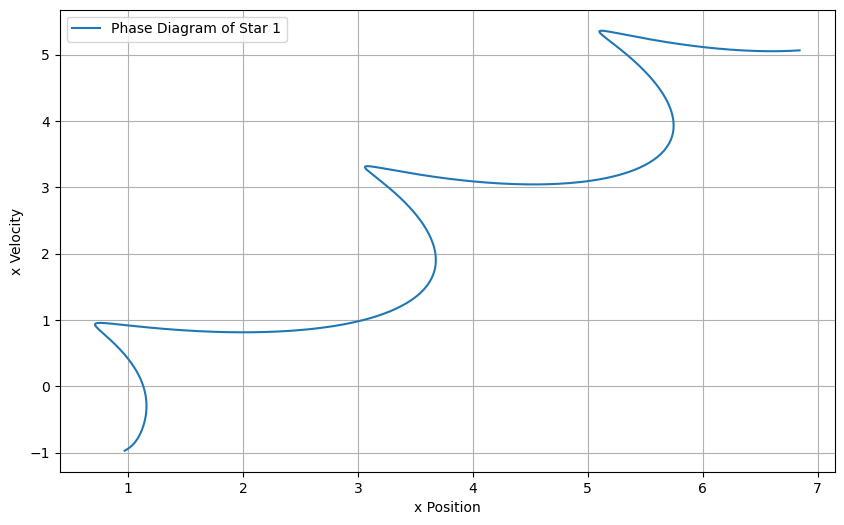

In [12]:
# I keep pertubring the initial conditions until one star gets ejected.

star1 = Stars(1.0, [0.97000436, -0.24308753], [0.55, 0.43236573])  
star2 = Stars(1.0, [-0.97000436, 0.24308753], [0.5, 0.5])           
star3 = Stars(1.0, [0.0, 0.0], [-1.5, -1.5])                


# Create three-body system with the chaotic initial conditions
three_body_system_chaotic = ThreeBodySystem([star1, star2, star3])
y0_chaotic = [*star1.position, *star2.position, *star3.position, *star1.velocity, *star2.velocity, *star3.velocity]
t_span_chaotic = (0, 20)

# Integrate using solve_ivp for chaotic system
solution_ivp_chaotic = three_body_system_chaotic.integrate_orbits(y0_chaotic, t_span_chaotic, method='RK45')

# Plot the trajectories for the chaotic solve_ivp solution
three_body_system_chaotic.plot_trajectories(solution_ivp_chaotic)
# Plot the phase diagram for one of the stars (Star 1)
three_body_system_chaotic.plot_phase_diagram(solution_ivp_chaotic, star_index=0)


##### Chaotic trajectories #####
I perturb velocity for chaos, when I plotted the trajectories for the three body system. I notice that Star 3 eventually gets ejected from the the system highlighting the unpredictable nature of the system as one star potentially escapes and the remaining 2 stars form a binary stable star system.

The trajectory of Star 3 shows a long, straight path extending away from the others. This indicates that the star has gained enough kinetic energy, likely through interactions with the other two stars, to escape the gravitational pull of the system.

In this chaotic system, the trajectories diagram is highly sensitive to initial conditions and does not show regular, closed orbits as in stable configurations.

The paths of star 1 and star 2 are irregular and spiraling, indicating that the motion of these stars is unpredictable and lacks periodicity, but after some time the two stars will form a stable binary system.


##### Phase plot #####

The phase diagram reveals multiple loops and turns, which are not organised in a repeating fashion. This suggests that Star 1 experiences varying gravitational forces due to the chaotic interactions with the other stars, leading to unpredictable acceleration and deceleration.



### 3.2 Problem 3: Triple hypergiant system  (20% of marks)

Model a triple system of hypergiants. Hypergiants are the most massive stars, and so they cannot be treated as point like objects. Now if they get within some user-specified distance of each other, they should merge into a single hypergiant with a combined mass of the two objects:

$M_{new} = M_1 + M_2$

The new star position should be set as the midpoint of the centres of the stars that merged, and (since momentum is conserved) we will also require that:

$(M_1 + M_2)\frac{dx_{new}}{dt} = M_1 \frac{dx_1}{dt} + M_2 \frac{dx_2}{dt}$

$(M_1 + M_2)\frac{dy_{new}}{dt} = M_1 \frac{dy_1}{dt} + M_2 \frac{dy_2}{dt}$
    

**Required Components**

1. The three hypergiants should have masses in the ratio of 0.8 : 1.0 : 1.2

2. You should make a hypergiant class that *inherits* from the star class. What extra attribute(s) and methods should it have? Implement them. One of these should provide an `__add__` function to manage the merger of two hypergiants.

3. Include defensive programming techniques such as asserts and tests of key functionality

4. Provide some documentation of the code implemented in markdown

_(HINT 1: For this problem it is usually easier to use your own midpoint/Runge Kutta method and not `solve_ivp()`, as it allows you more control over the merging process)_


# Triple hypergiant system


#### Hypergiant Class :


When hypergiants get close to each other, they will merge into a new, larger hypergiant.
Each of the three hypergiants has a different mass, they exert gravitational forces on each other causing them to move. If two hypergiants come too close (and they do not happen to move fast they will end up merging together), they will merge into a single new star with the combined mass and momentum of the original stars.
And to solve this problem, we start by defining a class called **Hypergiant** that inherits from the class **Stars**. The Hypergiant class has an extra attribute : `radius`.

The radius will be used in an if statement for example: " If the stars are within some distance ( small distance ) then:
- if too close : then merge them
- if not : do nothing and system remains a triple body system.

The Hypergiantclass has an additional `__add__()` method to manage merging. When two stars are close enough, their masses, positions, and velocities are combined.

   - The mass is simply the sum of the two initial star masses that have been merged together.
   - The position is the midpoint.
   - The velocity is updated based on the conservation of momentum.
   
So initially we start with three stars, at some time t ,two stars ( say star 1 and star 2 ) merge and form a hypergiant call it star 4. 
Star 3 and 4 can now do two things:

    1- Merge and form a hypergiant.
    2- Form a binary stable star system.
    
**Case 1** : If star 3 and star 4 merge at time T > t ,  if they are at a close distance , so then we relabel the hypergiant , which now has a new position, new velocity and a new mass. 

**Case 2** : The two stars 3 and 4 , form a binary system , each star moves at a velocity that keeps it in a consistent distance from the other, neither escaping nor merging.



#### StarSystems Class :

As before the class StarSystems represents the entire system of stars.
The `StarSystems` class is responsible for managing the interactions between multiple stars:
- The gravitational interactions are computed using Newton's Law.
- The `merge_stars()` method checks if stars are close enough to merge.
- The `integrate_midpoint()` method handles the numerical integration to solve for the motion over time.



#### What am I expecting to have at the end ?

I should end up with three plots : 

    1-Initial Plot: Showing the initial state with three stars.
    2-Intermediate Plot: After the first merging event when 2 stars merge and I end up with two stars.
    3-Final Plot: After the second merging event when two stars merge into one.

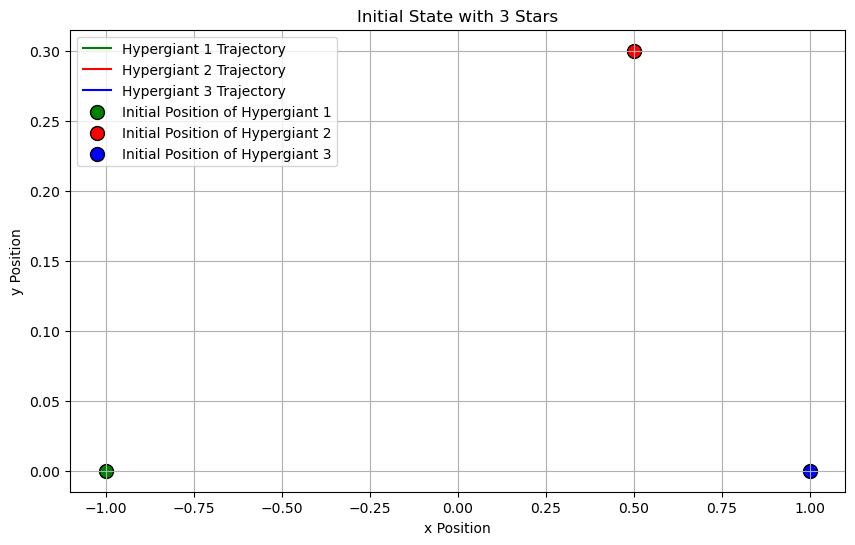

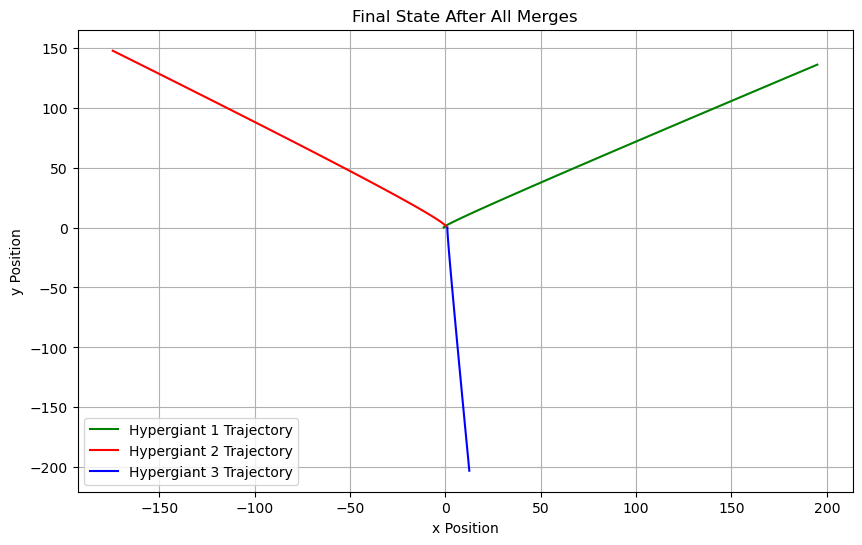

In [13]:
#Star Class
class Stars:
    def __init__(self, mass, position, velocity):
        if mass <= 0:
            raise ValueError("Mass must be a positive value.")
        if isinstance(position, (list, np.ndarray)) and len(position) == 2:
            self.position = np.array(position, dtype=float)
        else:
            raise ValueError("Position must be a list or numpy array of length 2.")
        if isinstance(velocity, (list, np.ndarray)) and len(velocity) == 2:
            self.velocity = np.array(velocity, dtype=float)
        else:
            raise ValueError("Velocity must be a list or numpy array of length 2.")
        self.mass = mass

    def __repr__(self):
        return f"Star(mass={self.mass}, position={self.position}, velocity={self.velocity})"


# Hypergiant class that inherits from the Star class
class Hypergiant(Stars):
    
    """ Class to represent a Hypergiant star in a gravitational system.

    Attributes:
    - mass (float): The mass of the hypergiant star.
    - position (np.array): The position of the hypergiant star in 2D space (x, y).
    - velocity (np.array): The velocity of the hypergiant star in 2D space (vx, vy).
    - radius (float): The radius of the hypergiant star, which influences merging behavior.

    Methods:
    - __add__: Combines two hypergiant stars into a single hypergiant if they merge.
    - Merges two hypergiants by:
      - Summing their masses.
      - Setting the position as the mass-weighted midpoint.
      - Calculating the velocity based on conservation of momentum.
      
      """
    def __init__(self, mass, position, velocity, radius):
        super().__init__(mass, position, velocity)
        if radius <= 0:
            raise ValueError("Radius must be a positive value.")
        self.radius = radius

    # Handles merging
    def __add__(self, other):
        if not isinstance(other, Hypergiant):
            raise ValueError("Can only add another Hypergiant.")
        
        # New Mass
        new_mass = self.mass + other.mass
        
        # New Position - mass-weighted midpoint
        new_position = (self.mass * self.position + other.mass * other.position) / new_mass
        
        # New Velocity - conservation of momentum
        new_velocity = (self.mass * self.velocity + other.mass * other.velocity) / new_mass
        
        # New Radius - assuming radii are additive for simplicity
        new_radius = self.radius + other.radius
        
        return Hypergiant(new_mass, new_position, new_velocity, new_radius)

    def __repr__(self):
        return f"Hypergiant(mass={self.mass}, position={self.position}, velocity={self.velocity}, radius={self.radius})"


# Defining the StarSystem class to manage interactions and merging
class StarSystem:
    
    """ Class to represent a system of interacting stars, including gravitational attraction and merging behavior.

    Attributes:
    - stars (list): List containing Hypergiant objects representing the stars in the system.
    - merge_distance (float): Distance threshold below which two stars merge.

    Methods:
    - compute_gravitational_acceleration: Computes gravitational acceleration due to another star.
    - merge_stars: Merges stars that are close enough based on the merge distance.
    - integrate_midpoint: Numerically integrates the system's dynamics using the midpoint method.
    - plot_trajectories: Plots the trajectories of all stars in the system.

    """
        
    def __init__(self, stars, merge_distance):
        self.stars = stars
        self.merge_distance = merge_distance

    # Method to compute gravitational forces
    def compute_gravitational_acceleration(self, star_index):
        G = 1  # Gravitational constant
        acceleration = np.zeros(2)
        target_star = self.stars[star_index]
        
        for i, star in enumerate(self.stars):
            if i != star_index:
                r_vector = star.position - target_star.position
                r = np.linalg.norm(r_vector)
                if r != 0:
                    acceleration += G * star.mass * r_vector / r**3

        return acceleration

    # Method to check and merge stars if they are close enough
    def merge_stars(self):
        merged = []
        n = len(self.stars)
        for i in range(n):
            for j in range(i + 1, n):
                if j not in merged and i not in merged:
                    distance = np.linalg.norm(self.stars[i].position - self.stars[j].position)
                    if distance < self.merge_distance:
                        new_star = self.stars[i] + self.stars[j]
                        self.stars[i] = new_star
                        merged.append(j)
        
        # Remove merged stars
        self.stars = [self.stars[i] for i in range(n) if i not in merged]

    # Integrate system using midpoint method
    def integrate_midpoint(self, y0, dt, t_span):
        t_values = np.arange(t_span[0], t_span[1] + dt, dt)
        y_values = [np.array(y0)]
        
        stage = 0  # Tracking merging stages

        for t in t_values[:-1]:
            self.merge_stars()  # Check if any stars need to be merged
            
            # Plot at the first merge (3 to 2 stars)
            if stage == 0 and len(self.stars) == 2:
                self.plot_trajectories(np.array(y_values), t_values[:len(y_values)], "After First Merge (3 -> 2 stars)")
                stage += 1

            # Plot at the second merge (2 to 1 star)
            elif stage == 1 and len(self.stars) == 1:
                self.plot_trajectories(np.array(y_values), t_values[:len(y_values)], "After Second Merge (2 -> 1 star)")
                stage += 1
            
            # Update the number of stars dynamically
            n = len(self.stars)
            
            # Extract positions and velocities
            y = np.array(y_values[-1])  # Convert to NumPy array before reshaping
            positions = y[:2 * n].reshape((n, 2))
            velocities = y[2 * n:].reshape((n, 2))
            
            # Compute accelerations
            accelerations = np.array([self.compute_gravitational_acceleration(i) for i in range(n)])
            
            # Midpoint calculation
            k1_positions = velocities * dt
            k1_velocities = accelerations * dt
            
            mid_positions = positions + 0.5 * k1_positions
            mid_velocities = velocities + 0.5 * k1_velocities
            
            # Update accelerations at midpoint
            mid_accelerations = np.array([self.compute_gravitational_acceleration(i) for i in range(n)])
            
            
            new_positions = positions + mid_velocities * dt
            new_velocities = velocities + mid_accelerations * dt
            
            # Flatten the updated positions and velocities
            new_state = np.concatenate([new_positions.flatten(), new_velocities.flatten()])
            y_values.append(new_state)

        # Plot the final trajectories
        self.plot_trajectories(np.array(y_values), t_values, "Final State After All Merges")
        
        return t_values, np.array(y_values)


    def plot_trajectories(self, results, t_values, title):
        plt.figure(figsize=(10, 6))

        n = len(self.stars)

        # Define color for each star
        colors = ['green', 'red', 'blue']
        
        for i in range(n):
            color = colors[i % len(colors)]  # Assign each star a color based on index
            plt.plot(results[:, 2 * i], results[:, 2 * i + 1], color=color, label=f"Hypergiant {i + 1} Trajectory")

        # Plot initial positions as blobs
        if "Initial" in title or "After First Merge" in title or "After Second Merge" in title:
            for i in range(n):
                color = colors[i % len(colors)]
                plt.scatter(results[0, 2 * i], results[0, 2 * i + 1], s=100, color=color, edgecolor='black', label=f"Initial Position of Hypergiant {i + 1}")

        plt.xlabel('x Position')
        plt.ylabel('y Position')
        plt.title(title)
        plt.legend()
        plt.grid()
        plt.show()


# Initialise hypergiants with given mass ratios and initial conditions
mass_ratios = [0.8, 1.0, 1.2]
positions = [[-1, 0], [1, 0], [0, np.sqrt(3)]]
velocities = [[0.5, 0.3], [-0.4, 0.6], [-0.1, -0.8]]
radii = [0.5, 0.6, 0.7]

hypergiants = [Hypergiant(mass * 10, pos, vel, rad) for mass, pos, vel, rad in zip(mass_ratios, positions, velocities, radii)]
merge_distance = 1.0 

# Create the star system
star_system = StarSystem(hypergiants, merge_distance)

# Initial conditions for integration
y0 = [x for star in hypergiants for x in (*star.position, *star.velocity)]
dt = 0.1
t_span = (0, 10)

# Plot initial state
star_system.plot_trajectories(np.array([y0]), [0], "Initial State with 3 Stars")

# Integrate system
t_values, results = star_system.integrate_midpoint(y0, dt, t_span)

#### First plot :

Initial State with 3 Stars plot : Shows the initial setup, where three distinct hypergiants are placed at specific positions and start moving under the influence of their gravitational forces.


#### Second plot :

Final State After All Merges plot : Displays the final outcome where all three hypergiants have eventually merged into a single massive hypergiant. The trajectories show the paths taken by each star until merging, and the subsequent motion of the final hypergiant.

The graph represents the trajectories that were taken by the hypergiants until the end of the simulation, at which point all stars have merged into one final entity.

The first two stars merge into a single larger hypergiant, which then continues to attract the third star, eventually merging to form a single hypergiant.

After the merging events, the resulting large hypergiant continues to move along a new trajectory.

